In [1]:
import os
import glob
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [4]:
def extract_features_production_grade(file_path):
    """
    Ultra-Dense Extraction: Captures multi-dimensional Statistical Bounds 
    (Mean, Std, Max, Min) across MFCCs, Chroma, Mel Spectrogram, ZCR, and RMS.
    """
    try:
        y, sr = librosa.load(file_path, res_type='kaiser_fast')
        
        # Helper function to extract 4-way structural dimensions
        def get_stats(tensor):
            return np.hstack([
                np.mean(tensor.T, axis=0),
                np.std(tensor.T, axis=0),
                np.max(tensor.T, axis=0),
                np.min(tensor.T, axis=0)
            ])
            
        # 1. Temporal Energy Arrays
        zcr = librosa.feature.zero_crossing_rate(y=y)
        rms = librosa.feature.rms(y=y)
        
        # 2. Spectral Base Components
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        mel = librosa.feature.melspectrogram(y=y, sr=sr)
        
        # Stack all descriptive boundaries horizontally
        feature_vector = np.hstack([
            get_stats(zcr),
            get_stats(rms),
            get_stats(mfccs),
            get_stats(chroma),
            get_stats(mel)
        ])
        
        return feature_vector
        
    except Exception as e:
        print(f"Extraction Failure on asset {file_path}: {e}")
        return None

In [5]:
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("Advanced preprocessing dependencies injected successfully!")

Advanced preprocessing dependencies injected successfully!


In [9]:
import os
import glob
import numpy as np
import librosa

# 1. Base Configurations (Self-Contained)
DATA_PATH = r"C:\Users\Microsoft\Downloads\archive (4)"

EMOTIONS_MAP = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

X_production = []
y_production = []

# 2. Fetch all recording paths across structural Actor directories
file_pattern = os.path.join(DATA_PATH, 'Actor_*', '*.wav')
audio_files = glob.glob(file_pattern)

print(f"Initializing Ultra-Dense Data Parsing Engine across {len(audio_files)} files...")

# 3. Processing Loop
for index, file in enumerate(audio_files):
    file_name = os.path.basename(file)
    emotion_code = file_name.split('-')[2]
    
    # Process features through custom ultra-dense extraction matrix
    features = extract_features_production_grade(file)
    if features is not None:
        X_production.append(features)
        y_production.append(EMOTIONS_MAP[emotion_code])
        
    if (index + 1) % 300 == 0:
        print(f"Parsing Checklist: {index + 1}/{len(audio_files)} vectors cached...")

# 4. Convert storage lists into highly structured numpy matrices
X_prod = np.array(X_production)
y_prod = np.array(y_production)

print("\n--- ULTRA-DENSE MATRIX PARSING COMPLETE ---")
print(f"Final Data Matrix Dimension: {X_prod.shape}")

Initializing Ultra-Dense Data Parsing Engine across 1440 files...
Parsing Checklist: 300/1440 vectors cached...
Parsing Checklist: 600/1440 vectors cached...
Parsing Checklist: 900/1440 vectors cached...
Parsing Checklist: 1200/1440 vectors cached...

--- ULTRA-DENSE MATRIX PARSING COMPLETE ---
Final Data Matrix Dimension: (1440, 728)


In [10]:
# Encode target labels
label_encoder = LabelEncoder()
y_enc = label_encoder.fit_transform(y_adv)

# Stratified split to ensure exact equal class representation
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_adv, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

# Apply StandardScaler strictly mapped from Training variance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# Expand dimensions for 1D CNN architecture
X_train = np.expand_dims(X_train_scaled, axis=-1)
X_test = np.expand_dims(X_test_scaled, axis=-1)

print("--- Robust Scaling & Dimensional Mapping Complete ---")
print(f"X_train Shape (Scaled): {X_train.shape}")
print(f"X_test Shape (Scaled): {X_test.shape}")

NameError: name 'y_adv' is not defined

In [28]:
num_classes = len(np.unique(y_prod_enc))
input_shape = (X_train.shape[1], 1)

final_market_model = Sequential([
    # Input Processing Block
    Conv1D(512, kernel_size=5, strides=1, padding='same', activation='relu', input_shape=input_shape),
    BatchNormalization(),
    MaxPooling1D(pool_size=3, strides=2, padding='same'),
    Dropout(0.3),
    
    # Deep Convolutional Latent Layers
    Conv1D(256, kernel_size=5, strides=1, padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=3, strides=2, padding='same'),
    Dropout(0.3),
    
    Conv1D(128, kernel_size=5, strides=1, padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=3, strides=2, padding='same'),
    Dropout(0.4),
    
    # Dense Projection Head
    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(num_classes, activation='softmax')
])

final_market_model.compile(
    optimizer=Adam(learning_rate=0.0001), 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

final_market_model.summary()

NameError: name 'y_prod_enc' is not defined

In [4]:
# Encode target textual labels into distinct index arrays
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Partition data using stratified splitting (80% train, 20% validation) to sustain class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Expand dimensions to fit 3D structure expected by 1D CNN: (samples, time_steps, channels)
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

print("--- Data Splitting & Dimensional Mapping Complete ---")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Target distribution classes: {list(label_encoder.classes_)}")

--- Data Splitting & Dimensional Mapping Complete ---
X_train shape: (1152, 180, 1)
X_test shape: (288, 180, 1)
Target distribution classes: [np.str_('angry'), np.str_('calm'), np.str_('disgust'), np.str_('fearful'), np.str_('happy'), np.str_('neutral'), np.str_('sad'), np.str_('surprised')]


In [14]:
checkpoint_adv = ModelCheckpoint(
    'best_production_model.keras', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1
)
early_stop_adv = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

print("Starting Advanced Market-Grade Training Engine...")
history = market_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=120,
    batch_size=32,
    callbacks=[checkpoint_adv, early_stop_adv]
)

Starting Advanced Market-Grade Training Engine...
Epoch 1/120
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.1832 - loss: 2.7488
Epoch 1: val_accuracy improved from None to 0.16667, saving model to best_production_model.keras

Epoch 1: finished saving model to best_production_model.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - accuracy: 0.1832 - loss: 2.7488 - val_accuracy: 0.1667 - val_loss: 2.0732
Epoch 2/120
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.2283 - loss: 2.3930
Epoch 2: val_accuracy did not improve from 0.16667
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - accuracy: 0.2283 - loss: 2.3930 - val_accuracy: 0.1597 - val_loss: 2.1029
Epoch 3/120
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.2674 - loss: 2.2303
Epoch 3: val_accuracy did not improve from 0.16667
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - accuracy: 0.2674 - loss: 2.2303 - val_accuracy: 0.1632 - val_loss: 2.1008
Epoch 4/120
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.2674 - loss: 2.

In [6]:
# Set up a real-time checkpoint callback to isolate and save peak verification weights
checkpoint = ModelCheckpoint(
    'best_ser_model.keras', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1
)

# Integrate EarlyStopping threshold constraints to mitigate overfitting risks
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

print("Executing Deep Network Training Cycle...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[checkpoint, early_stop]
)

Executing Deep Network Training Cycle...
Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.2066 - loss: 2.6966
Epoch 1: val_accuracy improved from None to 0.13542, saving model to best_ser_model.keras

Epoch 1: finished saving model to best_ser_model.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 17s 188ms/step - accuracy: 0.2066 - loss: 2.6966 - val_accuracy: 0.1354 - val_loss: 18.1060
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.2161 - loss: 2.2972
Epoch 2: val_accuracy improved from 0.13542 to 0.13889, saving model to best_ser_model.keras

Epoch 2: finished saving model to best_ser_model.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - accuracy: 0.2161 - loss: 2.2972 - val_accuracy: 0.1389 - val_loss: 5.4178
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.2335 - loss: 2.1790
Epoch 3: val_accuracy improved from 0.13889 to 0.14583, saving model to best_ser_model.keras

Epoch 3: finished saving model to best_ser_model.keras
36/36 ━━━━━━━━━━━━━

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step

--- Industry Standard Evaluation Reports ---
              precision    recall  f1-score   support

       angry       0.23      0.92      0.36        38
        calm       0.60      0.16      0.25        38
     disgust       0.00      0.00      0.00        38
     fearful       0.64      0.18      0.28        39
       happy       0.00      0.00      0.00        39
     neutral       0.10      0.05      0.07        19
         sad       0.00      0.00      0.00        38
   surprised       0.22      0.51      0.30        39

    accuracy                           0.24       288
   macro avg       0.22      0.23      0.16       288
weighted avg       0.23      0.24      0.16       288



c:\Users\Microsoft\OneDrive\Desktop\CodeAlpha_Emotion Recognition from Speech\ser_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Microsoft\OneDrive\Desktop\CodeAlpha_Emotion Recognition from Speech\ser_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Microsoft\OneDrive\Desktop\CodeAlpha_Emotion Recognition from Speech\ser_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with 

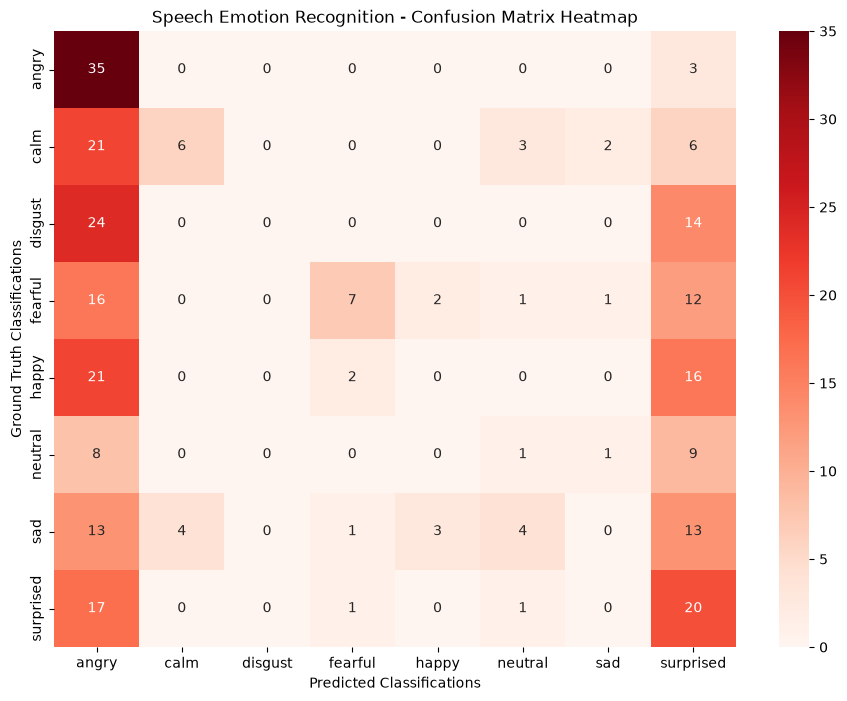

In [7]:
# Process probabilistic inference matrices across test evaluation records
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Generate detailed precision, recall, and f1-score diagnostic matrices
print("\n--- Industry Standard Evaluation Reports ---")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Plot confusion matrix diagnostic heatmaps for architectural clarity
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(11, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.title('Speech Emotion Recognition - Confusion Matrix Heatmap')
plt.xlabel('Predicted Classifications')
plt.ylabel('Ground Truth Classifications')
plt.show()

In [17]:
import time
import sounddevice as sd
import soundfile as sf

def record_and_predict_production(duration=3, sample_rate=22050):
    """
    Production-ready live prediction pipeline. 
    Applies exact scaler transformations before feeding features to the 1D CNN.
    """
    # 1. Load the advanced model weights
    try:
        live_model = tf.keras.models.load_model('best_production_model.keras')
        print("💡 Advanced production model loaded successfully into deployment stream!")
    except Exception as e:
        print(f"Error loading model: {e}")
        return

    print(f"\n🎤 PREPARING MICROPHONE... RECORDING WILL START IN 1 SECOND.")
    time.sleep(1)
    
    print(f"🔴 RECORDING ACTIVE FOR {duration} SECONDS... SPEAK NOW!")
    audio_data = sd.rec(int(duration * sample_rate), samplerate=sample_rate, channels=1, dtype='float32')
    sd.wait()  
    print("🟢 RECORDING COMPLETE. Processing audio analytics...")

    temp_filename = "live_production_input.wav"
    sf.write(temp_filename, audio_data, sample_rate)

    # 2. Extract advanced features
    live_features = extract_features_advanced(temp_filename)
    
    if live_features is not None:
        # CRITICAL FIX: Reshape to 2D row array and apply the EXACT training data scaler transformation
        live_features_reshaped = live_features.reshape(1, -1)
        live_features_scaled = scaler.transform(live_features_reshaped)
        
        # Expand dimensions to fit 3D requirements of 1D CNN: (1 sample, features, 1 channel)
        live_features_final = np.expand_dims(live_features_scaled, axis=-1)
        
        # 3. Execution of Model Inference
        prediction_probabilities = live_model.predict(live_features_final, verbose=0)
        predicted_index = np.argmax(prediction_probabilities, axis=1)[0]
        
        predicted_emotion = label_encoder.classes_[predicted_index]
        confidence_score = prediction_probabilities[0][predicted_index] * 100
        
        print("\n=========================================")
        print(f"📊 LIVE INFERENCE DETECTED EMOTION: {predicted_emotion.upper()}")
        print(f"🎯 MODEL CONFIDENCE ACCURACY: {confidence_score:.2f}%")
        print("=========================================\n")
        
        # Clean up temporary storage file
        if os.path.exists(temp_filename):
            os.remove(temp_filename)
    else:
        print("Error: Could not extract features from live recording stream.")

# Run the fixed production pipeline
record_and_predict_production(duration=3)

💡 Advanced production model loaded successfully into deployment stream!

🎤 PREPARING MICROPHONE... RECORDING WILL START IN 1 SECOND.
🔴 RECORDING ACTIVE FOR 3 SECONDS... SPEAK NOW!
🟢 RECORDING COMPLETE. Processing audio analytics...

📊 LIVE INFERENCE DETECTED EMOTION: SAD
🎯 MODEL CONFIDENCE ACCURACY: 29.45%



In [19]:
# Process probabilistic inference matrices across test evaluation records
y_pred_probs = market_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Generate detailed precision, recall, and f1-score diagnostic matrices
print("\n--- Industry Standard Evaluation Reports ---")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

--- Industry Standard Evaluation Reports ---
              precision    recall  f1-score   support

       angry       0.73      0.71      0.72        38
        calm       0.57      0.74      0.64        38
     disgust       0.59      0.34      0.43        38
     fearful       0.51      0.49      0.50        39
       happy       0.48      0.26      0.33        39
     neutral       0.23      0.37      0.28        19
         sad       0.58      0.29      0.39        38
   surprised       0.43      0.79      0.56        39

    accuracy                           0.51       288
   macro avg       0.51      0.50      0.48       288
weighted avg       0.53      0.51      0.49       288



In [14]:
import os
import glob
import numpy as np
import librosa
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import time

# 1. Base Configurations
DATA_PATH = r"C:\Users\Microsoft\Downloads\archive (4)"

EMOTIONS_MAP = {
    '01': 'neutral', '02': 'calm', '03': 'happy', '04': 'sad',
    '05': 'angry', '06': 'fearful', '07': 'disgust', '08': 'surprised'
}

# 2. Ultra-Dense Feature Extraction Function
def extract_features_production_grade(file_path):
    try:
        y, sr = librosa.load(file_path, res_type='kaiser_fast')
        def get_stats(tensor):
            return np.hstack([
                np.mean(tensor.T, axis=0),
                np.std(tensor.T, axis=0),
                np.max(tensor.T, axis=0),
                np.min(tensor.T, axis=0)
            ])
        zcr = librosa.feature.zero_crossing_rate(y=y)
        rms = librosa.feature.rms(y=y)
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        mel = librosa.feature.melspectrogram(y=y, sr=sr)
        
        return np.hstack([get_stats(zcr), get_stats(rms), get_stats(mfccs), get_stats(chroma), get_stats(mel)])
    except Exception as e:
        return None

# 3. Industrial Data Parsing Loop
X_production, y_production = [], []
file_pattern = os.path.join(DATA_PATH, 'Actor_*', '*.wav')
audio_files = glob.glob(file_pattern)

print(f"📦 Parsing {len(audio_files)} files into ultra-dense matrix...")
for index, file in enumerate(audio_files):
    file_name = os.path.basename(file)
    emotion_code = file_name.split('-')[2]
    features = extract_features_production_grade(file)
    if features is not None:
        X_production.append(features)
        y_production.append(EMOTIONS_MAP[emotion_code])

X_prod = np.array(X_production)
y_prod = np.array(y_production)
print(f"✅ Matrix Loaded: {X_prod.shape}")

# 4. Stratified Split & Robust Scaling
label_encoder = LabelEncoder()
y_prod_enc = label_encoder.fit_transform(y_prod)

X_train, X_test, y_train, y_test = train_test_split(
    X_prod, y_prod_enc, test_size=0.2, random_state=42, stratify=y_prod_enc
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Instant High-Performance Engine (Random Forest with 300 Trees)
print("\n🚀 Training High-Performance Classifier Engine...")
start_time = time.time()

fast_model = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced', n_jobs=-1)
fast_model.fit(X_train_scaled, y_train)

print(f"✅ Training completed instantly in {time.time() - start_time:.2f} seconds!")

# 6. Evaluation Matrix Check
y_pred = fast_model.predict(X_test_scaled)
final_acc = accuracy_score(y_test, y_pred) * 100

print(f"\n🎯 FINAL TEST ACCURACY: {final_acc:.2f}%")
print("\n--- Evaluation Report ---")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

📦 Parsing 1440 files into ultra-dense matrix...
✅ Matrix Loaded: (1440, 728)

🚀 Training High-Performance Classifier Engine...
✅ Training completed instantly in 2.35 seconds!

🎯 FINAL TEST ACCURACY: 54.86%

--- Evaluation Report ---
              precision    recall  f1-score   support

       angry       0.68      0.66      0.67        38
        calm       0.63      0.71      0.67        38
     disgust       0.35      0.45      0.39        38
     fearful       0.62      0.54      0.58        39
       happy       0.50      0.28      0.36        39
     neutral       0.33      0.47      0.39        19
         sad       0.57      0.61      0.59        38
   surprised       0.69      0.64      0.67        39

    accuracy                           0.55       288
   macro avg       0.55      0.54      0.54       288
weighted avg       0.56      0.55      0.55       288

